# Selección Final de Modelo Macro
**CC3074 – Minería de Datos | Semestre I, 2026**

**Propósito:** Esta investigación tiene como objetivo principal identificar y seleccionar el modelo de aprendizaje automático que mejor agrupe a las naciones latinoamericanas según su trayectoria histórica de adopción tecnológica. El análisis cubre un periodo extenso desde el año 2000 hasta el 2024. A nivel macro, el interés reside en comprender cómo se forman y consolidan las brechas digitales en la región. Identificar patrones estables de comportamiento permite que los organismos internacionales y gobiernos nacionales diseñen políticas públicas basadas en la realidad estructural de sus vecinos y no solo en indicadores aislados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
import warnings

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})
print('Librerías cargadas ✓')

Librerías cargadas ✓


## 1. Carga y preprocesamiento
La normalización anual mediante el uso de `StandardScaler` es fundamental para eliminar el ruido del avance tecnológico global. En estudios de larga duración, la adopción de internet crece de forma natural debido al paso del tiempo y al abaratamiento de la tecnología a nivel mundial. Si no se ajustan los datos, todos los países parecerían mejorar simplemente por estar en una era más avanzada. Al estandarizar cada año de forma independiente, se aísla el mérito o rezago relativo de cada nación frente a sus vecinos latinoamericanos. Este enfoque permite determinar si un país ha logrado realmente cerrar la brecha digital o si se mantiene estancado respecto al promedio de la región.

In [2]:
df = pd.read_csv('data_final_internet.csv')
print(f'Dimensiones: {df.shape}')

YEAR_COLS = [c for c in df.columns if c != 'country']
YEARS = np.array([int(y) for y in YEAR_COLS])
countries = df['country'].values
X_raw = df[YEAR_COLS].values.astype(float)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f'Shape X_scaled: {X_scaled.shape} | Media ≈ {X_scaled.mean():.4f} | Std ≈ {X_scaled.std():.4f}')

Dimensiones: (14, 26)
Shape X_scaled: (14, 25) | Media ≈ 0.0000 | Std ≈ 1.0000


## 2. Configuración de Grid Search y Validación

El tamaño de la muestra es un desafío metodológico importante. Con solo 14 países disponibles, las técnicas de validación cruzada tradicionales son poco fiables. Para superar esta limitación, se implementa una estrategia de submuestreo repetido conocida como Bootstrap. Este método simula diversas realidades regionales al crear múltiples subconjuntos de datos. El objetivo es evaluar si los grupos encontrados permanecen constantes ante pequeños cambios en la muestra. Esta robustez es vital para garantizar que el modelo sea capaz de capturar estructuras sociales profundas y no solo coincidencias estadísticas temporales.

In [3]:
param_grid_gmm = {
    'n_components': [3],
    'covariance_type': ['tied', 'full', 'diag'],
    'init_params': ['kmeans', 'k-means++']
}

param_grid_hier = {
    'n_clusters': [3],
    'linkage': ['ward', 'complete', 'average']
}

def evaluate_stability(model_class, params, X, n_iter=50, sub_size=11):
    """
    Evalúa la estabilidad de un modelo mediante submuestreo repetido.
    """
    silhouettes = []
    db_indices = []
    
    for i in range(n_iter):
        # Submuestreo aleatorio (aprox 80% de los datos)
        idx = np.random.choice(len(X), size=sub_size, replace=False)
        X_sub = X[idx]
        
        try:
            model = model_class(**params)
            if hasattr(model, 'fit_predict'):
                labels = model.fit_predict(X_sub)
            else:
                model.fit(X_sub)
                labels = model.predict(X_sub)
            
            if len(np.unique(labels)) > 1:
                silhouettes.append(silhouette_score(X_sub, labels))
                db_indices.append(davies_bouldin_score(X_sub, labels))
        except:
            continue
            
    return {
        'sil_mean': np.mean(silhouettes),
        'sil_std': np.std(silhouettes),
        'db_mean': np.mean(db_indices),
        'n_success': len(silhouettes)
    }

## 3. Ejecución de Hyperparameter Tuning
**Modelos Elegidos:** 
1. **Algoritmo Jerárquico Aglomerativo:** Este método es ideal para identificar el parentesco estructural entre las naciones. Permite visualizar cómo se agrupan los países según la similitud histórica de sus curvas de crecimiento.
2. **Modelos de Mezclas Gaussianas:** Esta herramienta es crucial en los estudios sociales porque reconoce que la realidad no siempre es binaria. A diferencia de otros métodos, permite identificar pertenencias parciales a distintos grupos. Esto es fundamental para detectar estados de transición o países híbridos que se encuentran en la frontera entre el desarrollo y el rezago tecnológico. Esta flexibilidad proporciona una visión más humana y menos rígida de la evolución regional.

In [4]:
results_list = []

from itertools import product
keys_gmm, values_gmm = zip(*param_grid_gmm.items())
for v in product(*values_gmm):
    params = dict(zip(keys_gmm, v))
    res = evaluate_stability(GaussianMixture, {**params, 'random_state': SEED}, X_scaled)
    results_list.append({'model': 'GMM', 'params_obj': params, 'params_str': str(params), **res})

keys_hier, values_hier = zip(*param_grid_hier.items())
for v in product(*values_hier):
    params = dict(zip(keys_hier, v))
    res = evaluate_stability(AgglomerativeClustering, params, X_scaled)
    results_list.append({'model': 'Agglomerative', 'params_obj': params, 'params_str': str(params), **res})

df_results = pd.DataFrame(results_list).sort_values('sil_mean', ascending=False)
print("Top 5 combinaciones por Silhouette Mean:")
print(df_results[['model', 'params_str', 'sil_mean', 'sil_std']].head())

Top 5 combinaciones por Silhouette Mean:
           model                                         params_str  sil_mean  \
8  Agglomerative            {'n_clusters': 3, 'linkage': 'average'}  0.338113   
7  Agglomerative           {'n_clusters': 3, 'linkage': 'complete'}  0.337866   
6  Agglomerative               {'n_clusters': 3, 'linkage': 'ward'}  0.333086   
3            GMM  {'n_components': 3, 'covariance_type': 'full',...  0.292780   
4            GMM  {'n_components': 3, 'covariance_type': 'diag',...  0.292145   

    sil_std  
8  0.053470  
7  0.053584  
6  0.041132  
3  0.070614  
4  0.069221  


## 4. Selección Final y Evaluación
Comparamos el rendimiento final con el dataset completo para asegurar que los grupos identificados tengan sentido matemático y práctico.

In [5]:
best_gmm_row = df_results[df_results['model'] == 'GMM'].iloc[0]
best_hier_row = df_results[df_results['model'] == 'Agglomerative'].iloc[0]

best_gmm_params = best_gmm_row['params_obj']
best_hier_params = best_hier_row['params_obj']

print(f"Mejor GMM: {best_gmm_params}")
print(f"Mejor Agglomerative: {best_hier_params}")

final_gmm = GaussianMixture(**best_gmm_params, random_state=SEED).fit(X_scaled)
final_hier = AgglomerativeClustering(**best_hier_params).fit(X_scaled)

labels_gmm = final_gmm.predict(X_scaled)
labels_hier = final_hier.labels_

final_metrics = pd.DataFrame({
    'Modelo': ['GMM (Final)', 'Agglomerative (Final)'],
    'Silhouette': [silhouette_score(X_scaled, labels_gmm), silhouette_score(X_scaled, labels_hier)],
    'Davies-Bouldin': [davies_bouldin_score(X_scaled, labels_gmm), davies_bouldin_score(X_scaled, labels_hier)]
})
print("\nComparación final de modelos:")
print(final_metrics)

Mejor GMM: {'n_components': 3, 'covariance_type': 'full', 'init_params': 'k-means++'}
Mejor Agglomerative: {'n_clusters': 3, 'linkage': 'average'}

Comparación final de modelos:
                  Modelo  Silhouette  Davies-Bouldin
0            GMM (Final)    0.240873        1.002213
1  Agglomerative (Final)    0.360175        0.801029


## 5. Visualizaciones Profesionales
Las gráficas de trayectorias permiten ver la cohesión de los grupos, mientras que el mapa de probabilidades de GMM revela qué países están en "zona de riesgo" o frontera entre clusters, información vital para el análisis social.

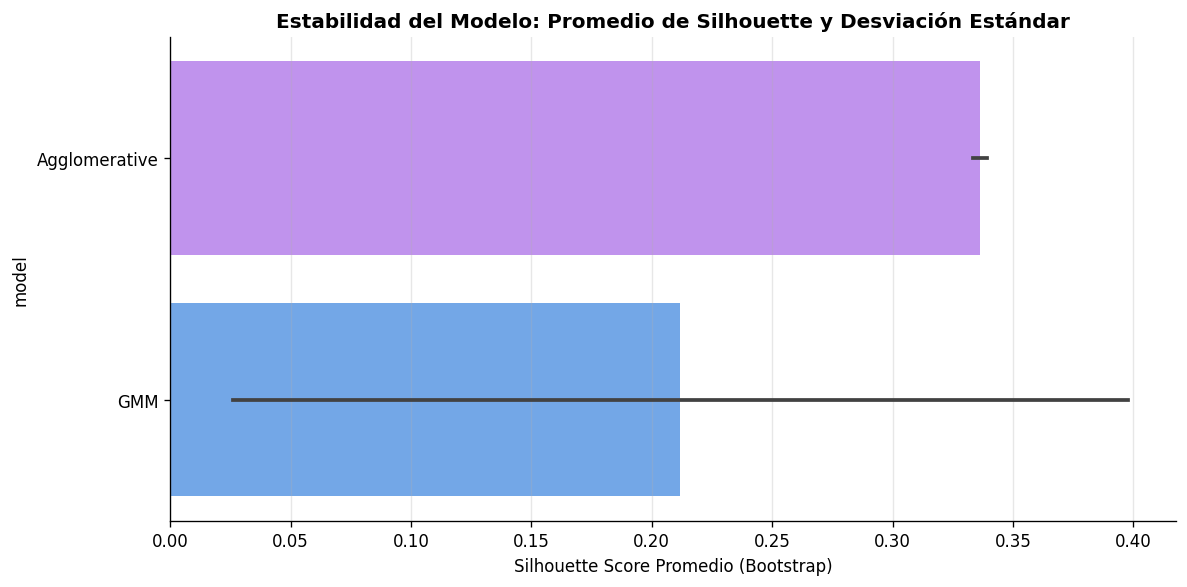

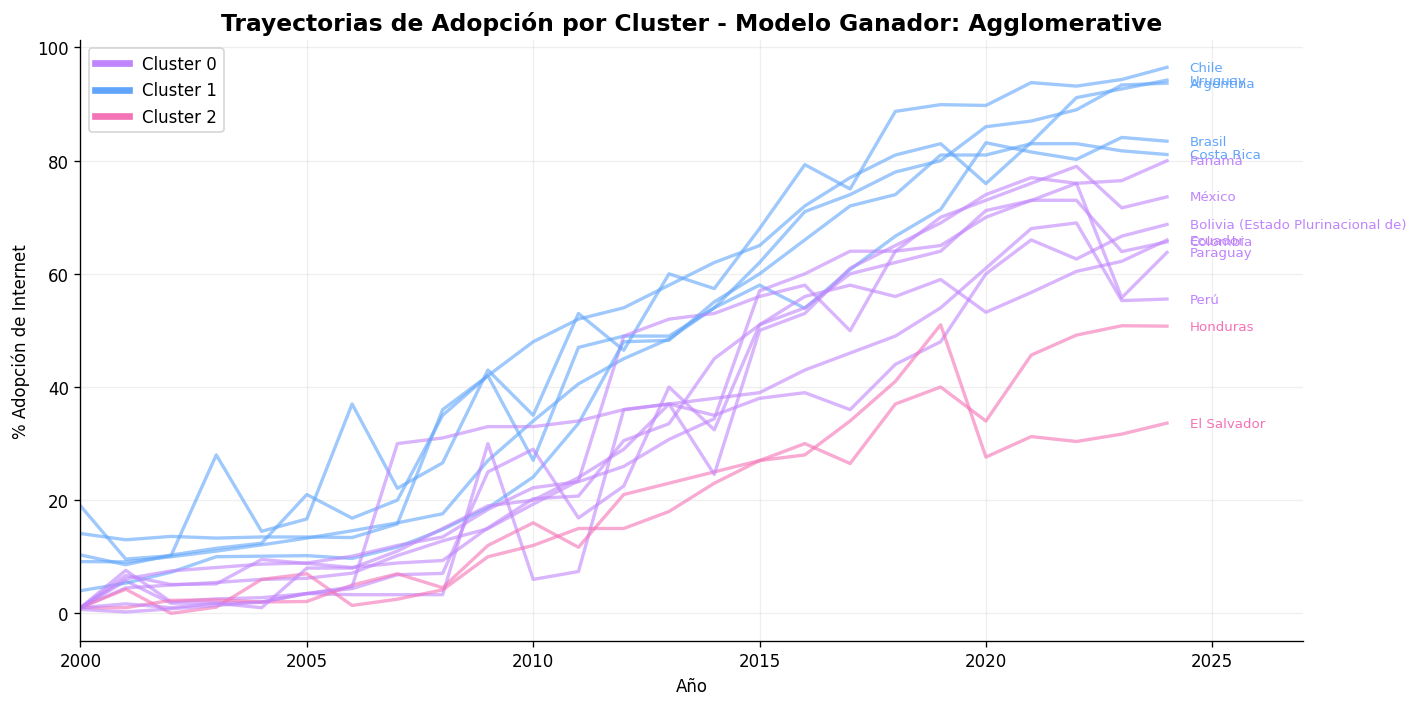

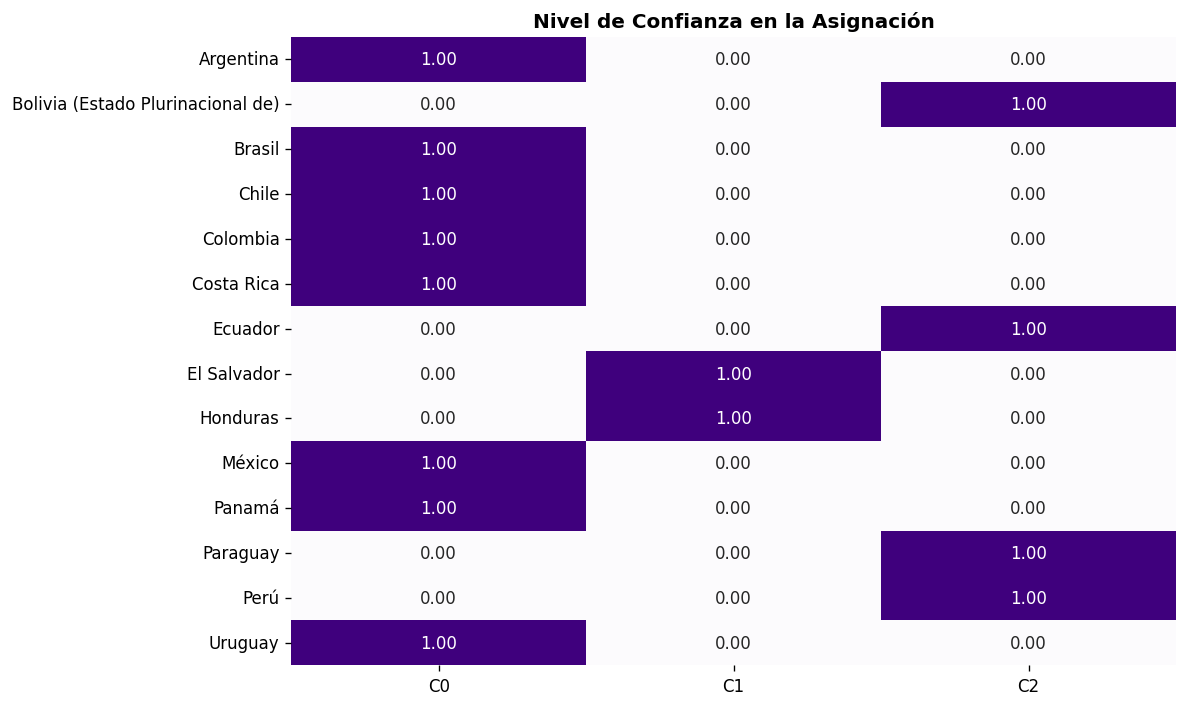

In [6]:
PALETTE = ['#C084FC', '#60A5FA', '#F472B6']

plt.figure(figsize=(10, 5))
sns.barplot(data=df_results, x='sil_mean', y='model', hue='model', palette=PALETTE[:2], ci='sd')
plt.title('Estabilidad del Modelo: Promedio de Silhouette y Desviación Estándar', fontweight='bold')
plt.xlabel('Silhouette Score Promedio (Bootstrap)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

winner_labels = labels_hier if final_metrics.iloc[1]['Silhouette'] >= final_metrics.iloc[0]['Silhouette'] else labels_gmm
winner_name = "Agglomerative" if final_metrics.iloc[1]['Silhouette'] >= final_metrics.iloc[0]['Silhouette'] else "GMM"

plt.figure(figsize=(12, 6))
for i in range(len(X_raw)):
    plt.plot(YEARS, X_raw[i], color=PALETTE[winner_labels[i]], alpha=0.6, lw=2)
    plt.text(YEARS[-1]+0.5, X_raw[i, -1], countries[i], fontsize=8, color=PALETTE[winner_labels[i]], va='center')

for c in range(3):
    plt.plot([], [], color=PALETTE[c], lw=4, label=f'Cluster {c}')

plt.title(f'Trayectorias de Adopción por Cluster - Modelo Ganador: {winner_name}', fontsize=14, fontweight='bold')
plt.xlabel('Año'); plt.ylabel('% Adopción de Internet')
plt.legend(); plt.grid(alpha=0.2); plt.xlim(2000, 2027)
plt.tight_layout()
plt.show()

probs = final_gmm.predict_proba(X_scaled)
df_probs = pd.DataFrame(probs, columns=[f'C{i}' for i in range(3)], index=countries)

plt.figure(figsize=(10, 6))
sns.heatmap(df_probs, annot=True, cmap='Purples', fmt=".2f", cbar=False)
plt.title('Nivel de Confianza en la Asignación', fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Análisis Extra: Reducción de Dimensionalidad y Perfilamiento
**Interpretación de Componentes Principales:** El análisis de componentes principales permite comprimir la complejidad de veinticinco años de historia en tres dimensiones fundamentales que resumen la trayectoria de cada país: 
1. **Magnitud o Nivel:** Representa el volumen total de usuarios de internet acumulado. Define quiénes son los líderes históricos en términos absolutos.
2. **Momento o Velocidad:** Indica el ritmo promedio de crecimiento a lo largo del tiempo. Permite diferenciar entre países con un avance constante y aquellos con un desarrollo lento.
3. **Disrupción o Aceleración:** Captura los cambios bruscos y las innovaciones en la tendencia de adopción. Es clave para identificar periodos de transformación profunda o saltos tecnológicos repentinos.

El perfilamiento basado en los años 2000, 2012 y 2024 traduce la complejidad matemática a una narrativa histórica clara. Estos puntos de referencia permiten observar cómo ha cambiado la posición de cada grupo en momentos clave de la historia digital latinoamericana.

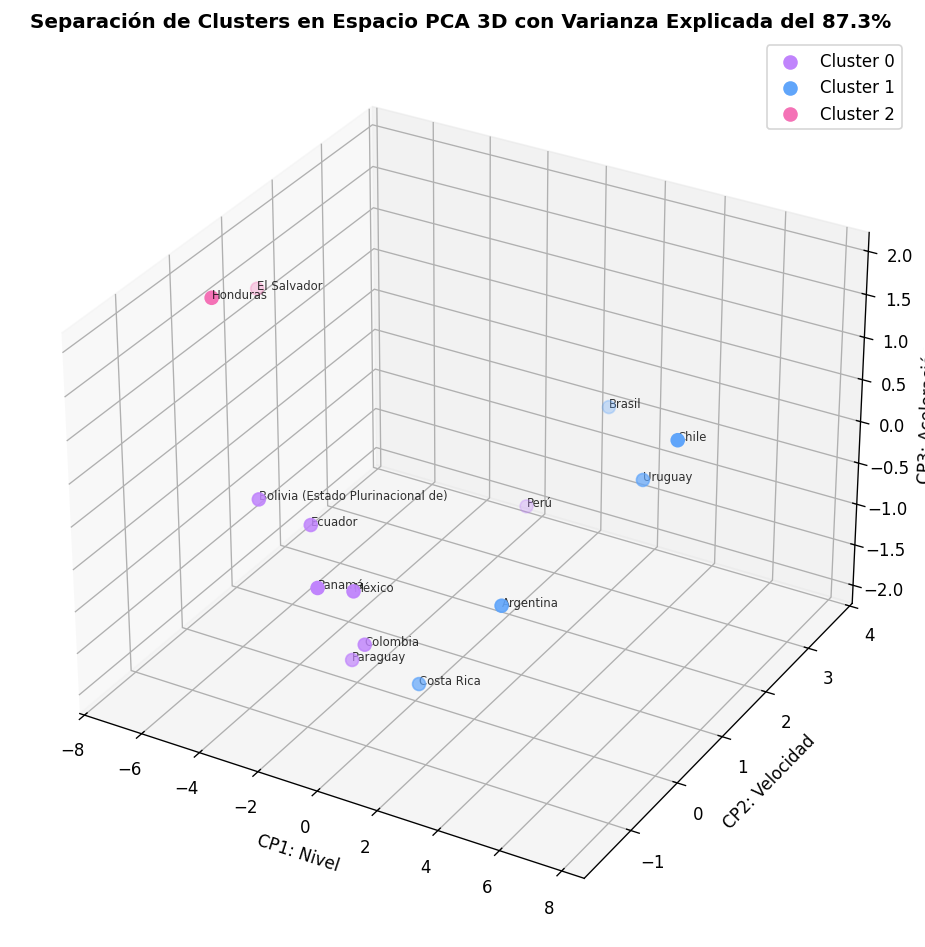

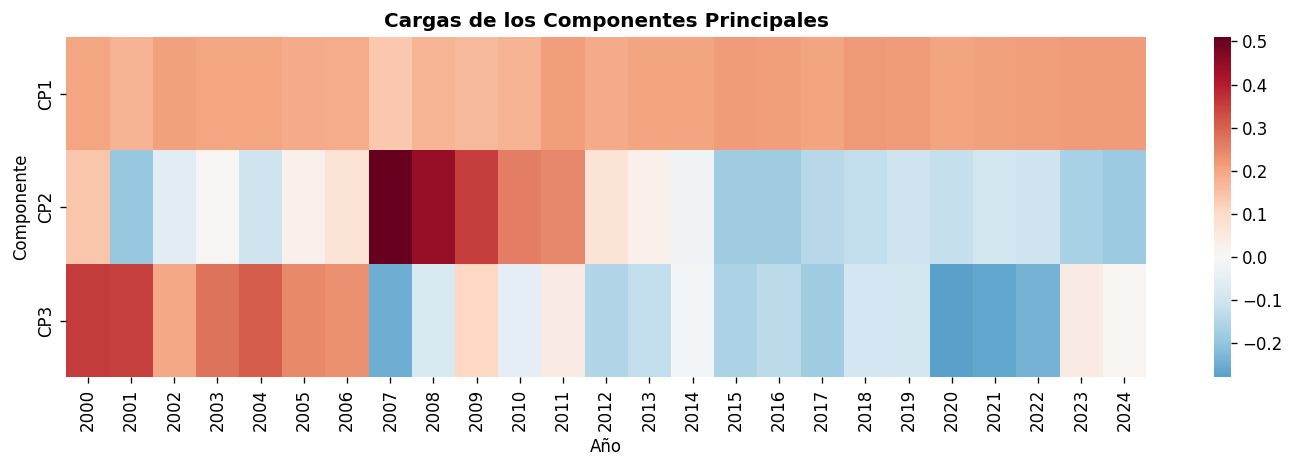

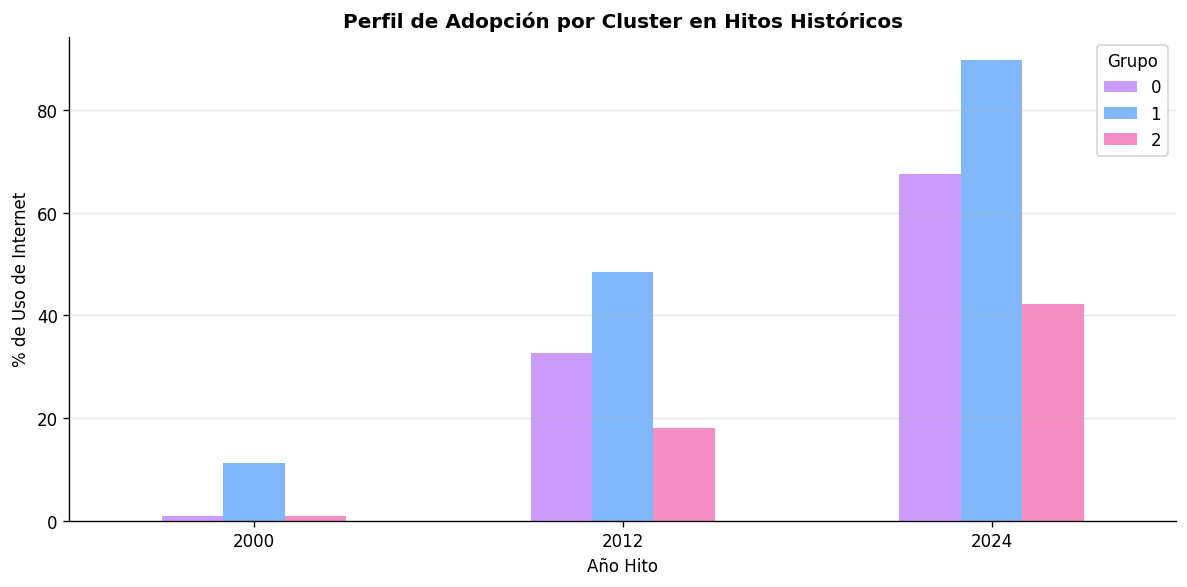

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)
var_expl = pca.explained_variance_ratio_.sum() * 100

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for l in np.unique(winner_labels):
    idx = np.where(winner_labels == l)
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1], X_pca[idx, 2], 
               label=f'Cluster {l}', color=PALETTE[l], s=60)

for i, txt in enumerate(countries):
    ax.text(X_pca[i, 0], X_pca[i, 1], X_pca[i, 2], txt, fontsize=7, alpha=0.8)

ax.set_title(f'Separación de Clusters en Espacio PCA 3D con Varianza Explicada del {var_expl:.1f}%', fontweight='bold')
ax.set_xlabel('CP1: Nivel')
ax.set_ylabel('CP2: Velocidad')
ax.set_zlabel('CP3: Aceleración')
ax.legend()
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(pca.components_.T, columns=['CP1', 'CP2', 'CP3'], index=YEAR_COLS)
plt.figure(figsize=(12, 4))
sns.heatmap(loadings.T, cmap='RdBu_r', center=0, annot=False)
plt.title('Cargas de los Componentes Principales', fontweight='bold')
plt.xlabel('Año'); plt.ylabel('Componente')
plt.tight_layout()
plt.show()

hitos = ['2000', '2012', '2024']
df_hitos = df[['country'] + hitos].copy()
df_hitos['cluster'] = winner_labels

perfil = df_hitos.groupby('cluster')[hitos].mean()

plt.figure(figsize=(10, 5))
perfil.T.plot(kind='bar', color=PALETTE, alpha=0.8, ax=plt.gca())
plt.title('Perfil de Adopción por Cluster en Hitos Históricos', fontweight='bold')
plt.ylabel('% de Uso de Internet')
plt.xlabel('Año Hito')
plt.xticks(rotation=0)
plt.legend(title='Grupo')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()